<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/ZahranAzariaAnvaya_2411531005_ML2526/blob/main/Praktikum5/TugasCrossValidation_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Training**

1. Import library yang dibutuhkan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression=
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

2. Load dataset, dan pisahkan variabel independent dan variabel dependent

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ML/Dataset/train.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Praproses Data

In [ ]:
# Cek missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Pilih fitur yang relevan
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target   = 'Survived'

df = df[features + [target]].copy()

# Tangani missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encoding variabel kategorikal
le = LabelEncoder()
df['Sex']      = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

print("Dataset setelah praproses:")
df.head()

Dataset setelah praproses:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

4. Implementasikan K-Fold Cross Validation (K=5)

In [ ]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

acc_list_k5 = []

for train_index, test_index in kf5.split(X):
    X_train_k, X_test_k = X.iloc[train_index], X.iloc[test_index]
    y_train_k, y_test_k = y.iloc[train_index], y.iloc[test_index]

    model_k5 = LogisticRegression(max_iter=1000)
    model_k5.fit(X_train_k, y_train_k)

    y_pred_k5 = model_k5.predict(X_test_k)
    acc_k5    = accuracy_score(y_test_k, y_pred_k5)

    acc_list_k5.append(acc_k5)

print("\n=== K-Fold Manual (K=5) ===")
print("Accuracy tiap fold:", acc_list_k5)
print("Accuracy rata-rata:", np.mean(acc_list_k5))


=== K-Fold Manual (K=5) ===
Accuracy tiap fold: [0.8100558659217877, 0.7921348314606742, 0.8426966292134831, 0.7752808988764045, 0.7865168539325843]
Accuracy rata-rata: 0.8013370158809867


5. Implementasikan K-Fold Cross Validation (K=10)

In [ ]:
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

acc_list_k10 = []

for train_index, test_index in kf10.split(X):
    X_train_k, X_test_k = X.iloc[train_index], X.iloc[test_index]
    y_train_k, y_test_k = y.iloc[train_index], y.iloc[test_index]

    model_k10 = LogisticRegression(max_iter=1000)
    model_k10.fit(X_train_k, y_train_k)

    y_pred_k10 = model_k10.predict(X_test_k)
    acc_k10    = accuracy_score(y_test_k, y_pred_k10)

    acc_list_k10.append(acc_k10)

print("\n=== K-Fold Manual (K=10) ===")
print("Accuracy tiap fold:", acc_list_k10)
print("Accuracy rata-rata:", np.mean(acc_list_k10))


=== K-Fold Manual (K=10) ===
Accuracy tiap fold: [0.8444444444444444, 0.7752808988764045, 0.8202247191011236, 0.7640449438202247, 0.797752808988764, 0.8314606741573034, 0.7865168539325843, 0.7415730337078652, 0.7303370786516854, 0.8426966292134831]
Accuracy rata-rata: 0.7934332084893883


6. Metrik Evaluasi dan Analisis

In [ ]:
# Evaluasi metrik lengkap menggunakan cross_val_score
model = LogisticRegression(max_iter=1000)

for k in [5, 10]:
    print(f"\n=== K-Fold dengan cross_val_score (K={k}) ===")
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        scores = cross_val_score(model, X, y, cv=k, scoring=metric)
        print(f"{metric.capitalize():10s} tiap fold: {scores.round(4)}  |  rata-rata: {scores.mean():.4f}")


=== K-Fold dengan cross_val_score (K=5) ===
Accuracy   tiap fold: [0.7877 0.7865 0.7809 0.7697 0.8202]  |  rata-rata: 0.7890
Precision  tiap fold: [0.7183 0.7273 0.7101 0.7368 0.8033]  |  rata-rata: 0.7392
Recall     tiap fold: [0.7391 0.7059 0.7206 0.6176 0.7101]  |  rata-rata: 0.6987
F1         tiap fold: [0.7286 0.7164 0.7153 0.672  0.7538]  |  rata-rata: 0.7172

=== K-Fold dengan cross_val_score (K=10) ===
Accuracy   tiap fold: [0.7889 0.7978 0.764  0.8202 0.7865 0.7753 0.7865 0.7865 0.809  0.8427]  |  rata-rata: 0.7957
Precision  tiap fold: [0.7222 0.7353 0.7407 0.7368 0.6923 0.7333 0.7778 0.7586 0.7931 0.8182]  |  rata-rata: 0.7508
Recall     tiap fold: [0.7429 0.7353 0.5882 0.8235 0.7941 0.6471 0.6176 0.6471 0.6765 0.7714]  |  rata-rata: 0.7044
F1         tiap fold: [0.7324 0.7353 0.6557 0.7778 0.7397 0.6875 0.6885 0.6984 0.7302 0.7941]  |  rata-rata: 0.7240


In [ ]:
model = LogisticRegression(max_iter=1000)

precision_k5 = cross_val_score(model, X, y, cv=5, scoring='precision').mean()
recall_k5    = cross_val_score(model, X, y, cv=5, scoring='recall').mean()
precision_k10 = cross_val_score(model, X, y, cv=10, scoring='precision').mean()
recall_k10    = cross_val_score(model, X, y, cv=10, scoring='recall').mean()

metrics_data = {
    'K-Fold': ['K=5', 'K=5', 'K=10', 'K=10'],
    'Metric': ['Precision', 'Recall', 'Precision', 'Recall'],
    'Score': [precision_k5, recall_k5, precision_k10, recall_k10]
}
metrics_df = pd.DataFrame(metrics_data)

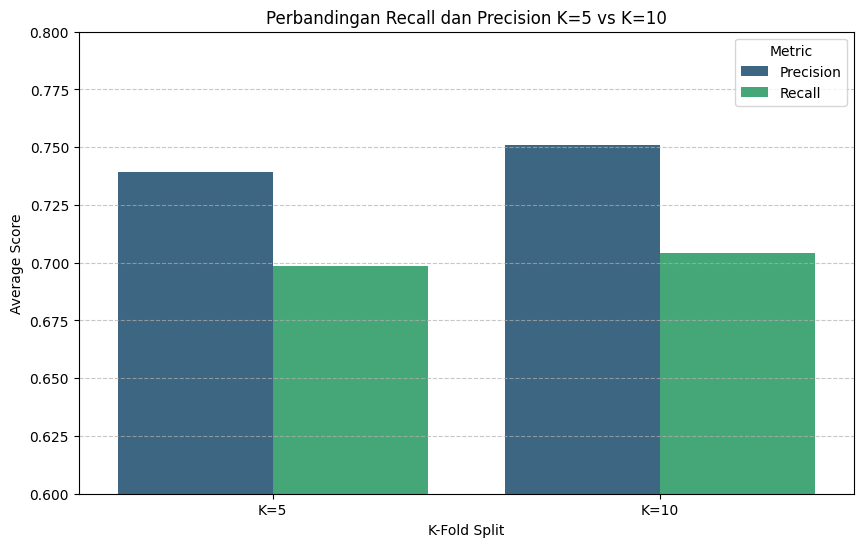

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='K-Fold', y='Score', hue='Metric', data=metrics_df, palette='viridis')
plt.title('Perbandingan Recall dan Precision K=5 vs K=10')
plt.xlabel('K-Fold Split')
plt.ylabel('Average Score')
plt.ylim(0.6, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

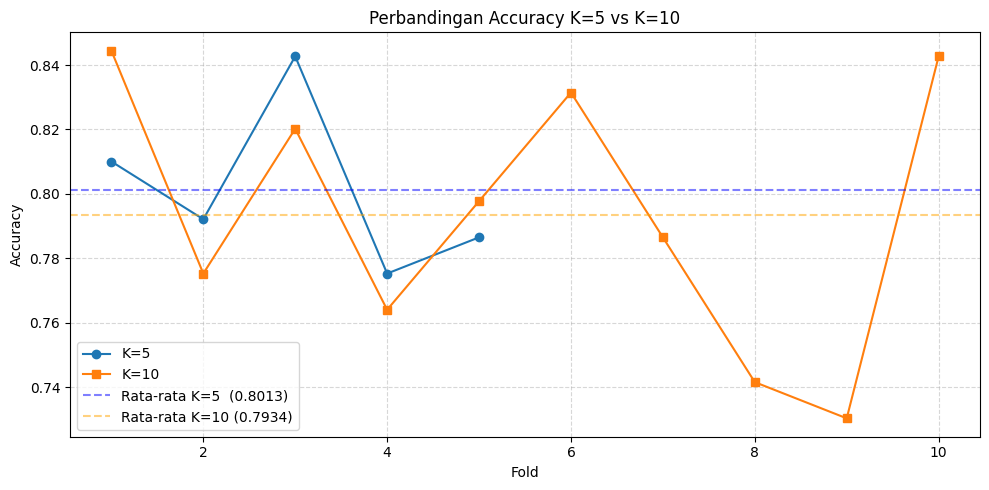

In [ ]:
# Visualisasi perbandingan accuracy K=5 vs K=10
plt.figure(figsize=(10, 5))

plt.plot(range(1, 6),  acc_list_k5,  marker='o', label='K=5')
plt.plot(range(1, 11), acc_list_k10, marker='s', label='K=10')

plt.axhline(np.mean(acc_list_k5),  linestyle='--', color='blue',  alpha=0.5, label=f'Rata-rata K=5  ({np.mean(acc_list_k5):.4f})')
plt.axhline(np.mean(acc_list_k10), linestyle='--', color='orange', alpha=0.5, label=f'Rata-rata K=10 ({np.mean(acc_list_k10):.4f})')

plt.title('Perbandingan Accuracy K=5 vs K=10')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **Data Testing**

1. Load Dataset

In [ ]:
# Load data test dan kunci jawaban
TEST_PATH   = "/content/drive/MyDrive/ML/Dataset/test.csv"
LABEL_PATH  = "/content/drive/MyDrive/ML/Dataset/gender_submission.csv"

df_test  = pd.read_csv(TEST_PATH)
df_label = pd.read_csv(LABEL_PATH)

print("Shape data test  :", df_test.shape)
print("Shape kunci jawaban:", df_label.shape)
df_test.head()

Shape data test  : (418, 11)
Shape kunci jawaban: (418, 2)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


2. Lakukan Praprosess Data

In [ ]:
# Praproses data test
df_test = df_test[features].copy()

# Tangani missing values
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())
df_test['Embarked'] = df_test['Embarked'].fillna(df_test['Embarked'].mode()[0])

# Encoding variabel kategorikal
le2 = LabelEncoder()
df_test['Sex']      = le2.fit_transform(df_test['Sex'])
df_test['Embarked'] = le2.fit_transform(df_test['Embarked'])

print("Missing values data test setelah praproses:")
print(df_test.isnull().sum())
df_test.head()

Missing values data test setelah praproses:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,1
1,3,0,47.0,1,0,7.0000,2
2,2,1,62.0,0,0,9.6875,1
3,3,1,27.0,0,0,8.6625,2
4,3,0,22.0,1,1,12.2875,2


3. Latih model final dengan seluruh data train

In [ ]:
# (model terbaik yang siap diuji ke data test)
model_final = LogisticRegression(max_iter=1000)
model_final.fit(X, y)

print("Model final berhasil dilatih menggunakan seluruh data train.")

Model final berhasil dilatih menggunakan seluruh data train.


4. Lakukan prediksi pada data baru menggunakan model yang sudah dibuat

In [ ]:
# Prediksi menggunakan data test
X_test_final = df_test
y_pred_final = model_final.predict(X_test_final)

# Ambil label sebenarnya dari gender_submission.csv
y_true_final = df_label['Survived'].values

print("Prediksi selesai!")
print(f"Jumlah data test : {len(y_pred_final)}")
print(f"Prediksi selamat : {y_pred_final.sum()}")
print(f"Prediksi tidak   : {(y_pred_final == 0).sum()}")

Prediksi selesai!
Jumlah data test : 418
Prediksi selamat : 157
Prediksi tidak   : 261


5. Evaluasi hasil prediksi yang didapatkan

In [ ]:
# Hitung metrik evaluasi pada data test
acc_test  = accuracy_score(y_true_final, y_pred_final)
prec_test = precision_score(y_true_final, y_pred_final)
rec_test  = recall_score(y_true_final, y_pred_final)
f1_test   = f1_score(y_true_final, y_pred_final)

print("=== Evaluasi Model pada Data Test ===")
print(f"Accuracy  : {acc_test:.4f}")
print(f"Precision : {prec_test:.4f}")
print(f"Recall    : {rec_test:.4f}")
print(f"F1-Score  : {f1_test:.4f}")
print()
print("Classification Report:")
print(classification_report(y_true_final, y_pred_final, target_names=['Tidak Selamat', 'Selamat']))

=== Evaluasi Model pada Data Test ===
Accuracy  : 0.9402
Precision : 0.9045
Recall    : 0.9342
F1-Score  : 0.9191

Classification Report:
               precision    recall  f1-score   support

Tidak Selamat       0.96      0.94      0.95       266
      Selamat       0.90      0.93      0.92       152

     accuracy                           0.94       418
    macro avg       0.93      0.94      0.94       418
 weighted avg       0.94      0.94      0.94       418



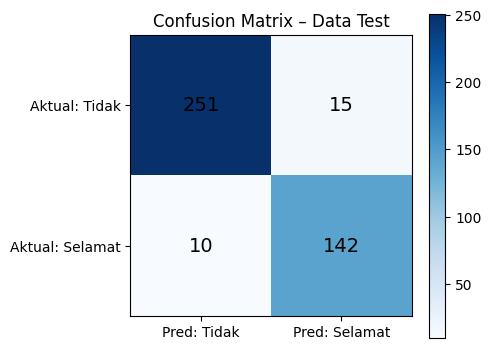

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix – Data Test')
plt.colorbar()
plt.xticks([0, 1], ['Pred: Tidak', 'Pred: Selamat'])
plt.yticks([0, 1], ['Aktual: Tidak', 'Aktual: Selamat'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, color='black')

plt.tight_layout()
plt.show()

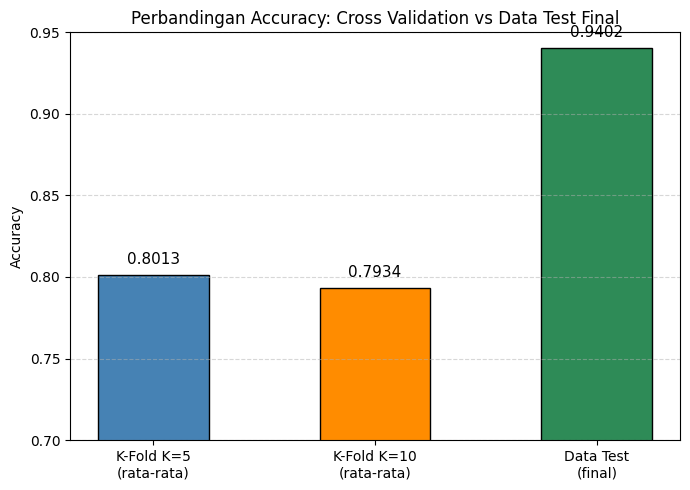

In [ ]:
# Perbandingan Accuracy: CV K=5 vs CV K=10 vs Data Test Sesungguhnya
labels  = ['K-Fold K=5\n(rata-rata)', 'K-Fold K=10\n(rata-rata)', 'Data Test\n(final)']
values  = [np.mean(acc_list_k5), np.mean(acc_list_k10), acc_test]
colors  = ['steelblue', 'darkorange', 'seagreen']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.title('Perbandingan Accuracy: Cross Validation vs Data Test Final')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.95)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()